# Visualise all the locations

In [1]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [2]:
CONFIG_FILE_NAME = "config.toml"
data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config(CONFIG_FILE_NAME) # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [3]:
print(gep_ed_data.keys())

dict_keys(['representative_period_weight', 'value_of_lost_load', 'ramping_value', 'demand_data', 'generation_data', 'generation_availability_data', 'transmission_lines_data', 'times', 'nodes', 'generators', 'transmission_lines', 'crossover', 'rounding', 'output_file', 'output_log', 'ramping', 'relaxed'])


In [4]:
print(f"All the locations:")
print(gep_ed_data["nodes"])
print(f"Lines between locations:")
print(gep_ed_data["transmission_lines"])

All the locations:
['AUS', 'BEL', 'BLK', 'BLT', 'CZE', 'DEN', 'FIN', 'FRA', 'GER', 'IRE', 'ITA', 'NED', 'NOR', 'POL', 'POR', 'SKO', 'SPA', 'SWE', 'SWI', 'UKI']
Lines between locations:
[('AUS', 'BLK'), ('AUS', 'CZE'), ('AUS', 'GER'), ('AUS', 'ITA'), ('AUS', 'SWI'), ('BEL', 'FRA'), ('BEL', 'GER'), ('BEL', 'NED'), ('BEL', 'UKI'), ('BLK', 'ITA'), ('BLK', 'SKO'), ('BLT', 'FIN'), ('BLT', 'POL'), ('BLT', 'SWE'), ('CZE', 'GER'), ('CZE', 'SKO'), ('DEN', 'NED'), ('DEN', 'NOR'), ('DEN', 'SWE'), ('DEN', 'UKI'), ('FIN', 'SWE'), ('FRA', 'IRE'), ('FRA', 'ITA'), ('FRA', 'UKI'), ('GER', 'DEN'), ('GER', 'FRA'), ('GER', 'NED'), ('GER', 'NOR'), ('GER', 'SWE'), ('GER', 'UKI'), ('NED', 'NOR'), ('NED', 'UKI'), ('NOR', 'UKI'), ('POL', 'CZE'), ('POL', 'GER'), ('POL', 'SKO'), ('POL', 'SWE'), ('SPA', 'FRA'), ('SPA', 'POR'), ('SWE', 'NOR'), ('SWI', 'FRA'), ('SWI', 'GER'), ('SWI', 'ITA'), ('UKI', 'IRE')]


In [5]:
# print(gep_ed_data["genenodesrators"]) 
# Get the one with (NED,*)
# Filter the list for tuples starting with 'NED'


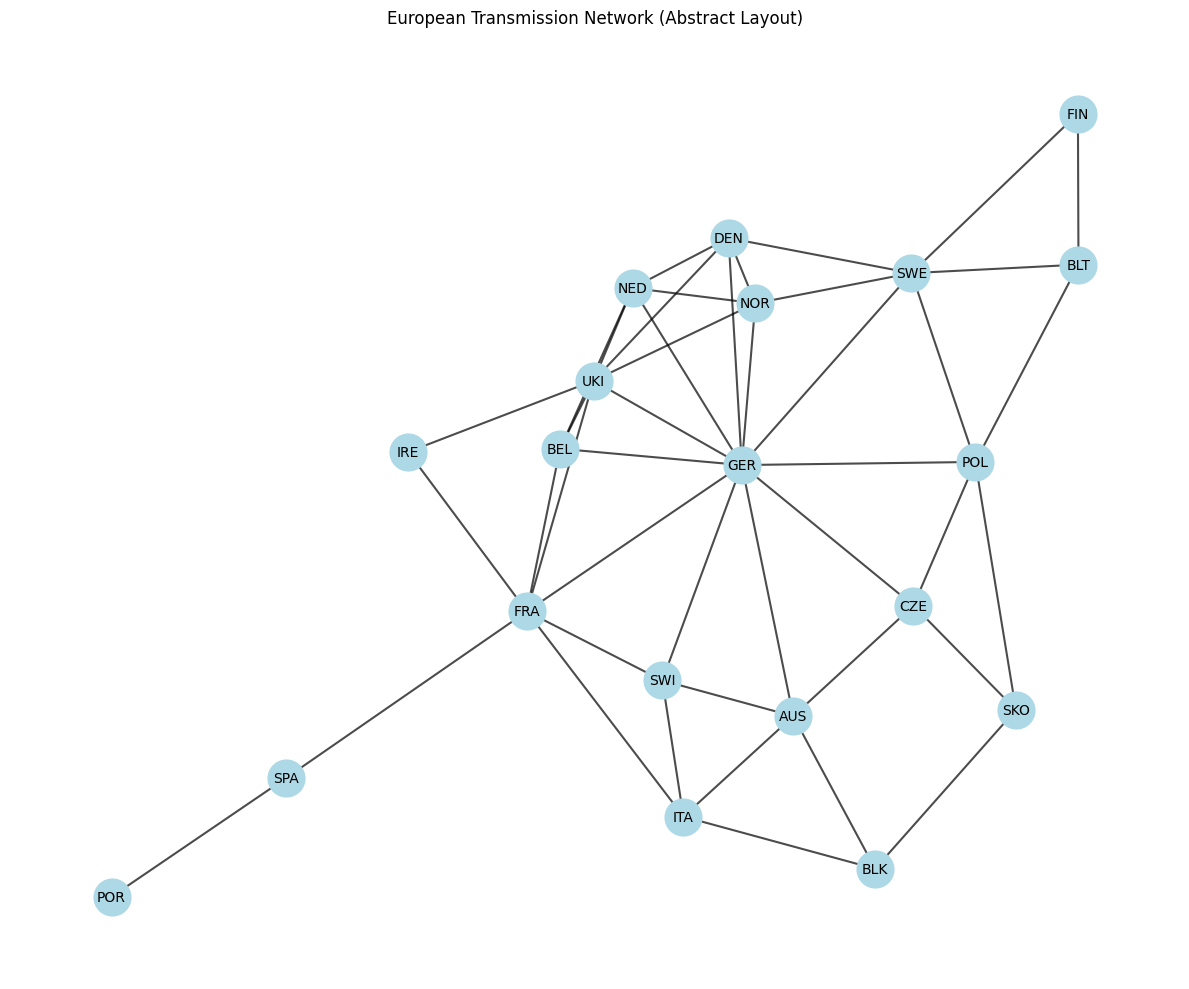

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
nodes = gep_ed_data["nodes"]
edges = gep_ed_data["transmission_lines"]

# Build graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network (Abstract Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
!pwd

/Users/peterhuang/Desktop/Delft/Year-2/THESIS/MasterThesis-GraphPDL


In [8]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_subgraph(
    nodes,
    edges,
    selected_nodes,
    layout_seed=42,
    figsize=(6, 4),
    node_size=800,
    node_color="lightblue",
    edge_width=2.0,
):
    """
    Plot only selected nodes and edges between them.

    nodes: list of all nodes
    edges: list of (u, v) edges
    selected_nodes: list or set of nodes to plot
    """

    # Build full graph
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Induced subgraph
    SG = G.subgraph(selected_nodes).copy()

    # Layout on subgraph only
    pos = nx.spring_layout(SG, seed=layout_seed)

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(SG, pos, node_size=node_size, node_color=node_color)
    nx.draw_networkx_edges(SG, pos, width=edge_width)
    nx.draw_networkx_labels(SG, pos, font_size=10)

    plt.title(f"Subgraph ({len(SG.nodes)} nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


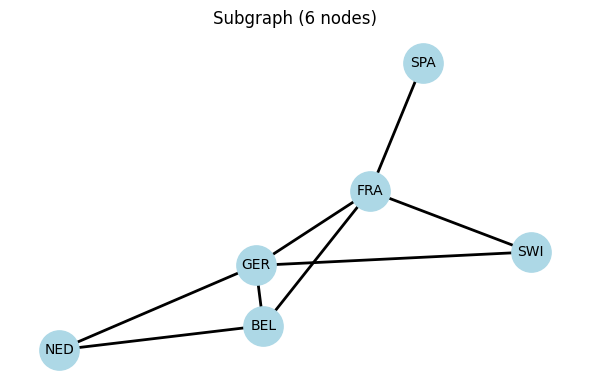

In [9]:
selected = ["GER", "FRA", "NED", "BEL","SPA","SWI"]
plot_subgraph(nodes, edges, selected)



## Select a 4th country

To join original experiment with:
- BEL
- GER
- FRA

In [10]:
ned_generators = [gen for gen in gep_ed_data["generators"] if gen[0] == 'SWI']
print("Generators in SWI:")
print(ned_generators)
print(f"Lines with SWI:")
swiss_lines = [line for line in gep_ed_data["transmission_lines"] if 'SWI' in line]
print(swiss_lines)

Generators in SWI:
[('SWI', 'Nuclear'), ('SWI', 'SunPV'), ('SWI', 'WindOff'), ('SWI', 'WindOn')]
Lines with SWI:
[('AUS', 'SWI'), ('SWI', 'FRA'), ('SWI', 'GER'), ('SWI', 'ITA')]


In [15]:
def plot_data_topology(data_path, name):
    data = pickle.load(open(data_path, 'rb'))
    print(data.N)
    print(data.L)

    # Build graph
    nodes = data.N
    edges = data.L
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Layout
    pos = nx.spring_layout(G, seed=42)  # reproducible

    # Plot
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title(name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

['BEL', 'GER', 'FRA']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA')]


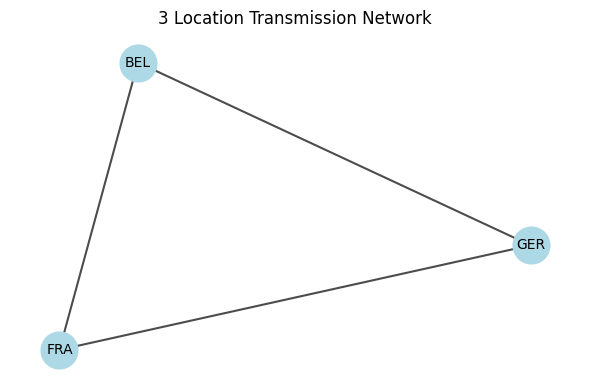

In [21]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl", name="3 Location Transmission Network")

['BEL', 'GER', 'FRA', 'SPA']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SPA', 'FRA')]


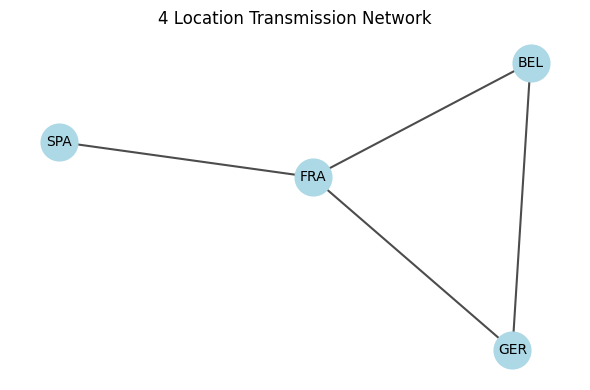

In [22]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_smp15.pkl", name="4 Location Transmission Network")

['BEL', 'GER', 'FRA', 'SPA', 'NED']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SPA', 'FRA'), ('BEL', 'NED'), ('GER', 'NED')]


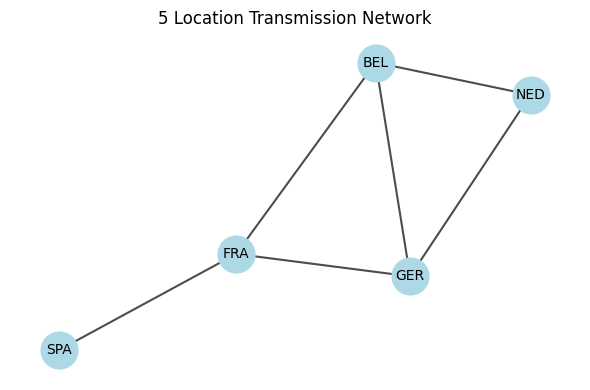

In [23]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S-N_GB2-G2-F2-S2-N2_L6_c0_s0_p0_smp15.pkl", name = "5 Location Transmission Network")

['BEL', 'GER', 'FRA', 'SPA', 'NED', 'SWI']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SPA', 'FRA'), ('BEL', 'NED'), ('GER', 'NED'), ('SWI', 'FRA'), ('SWI', 'GER')]


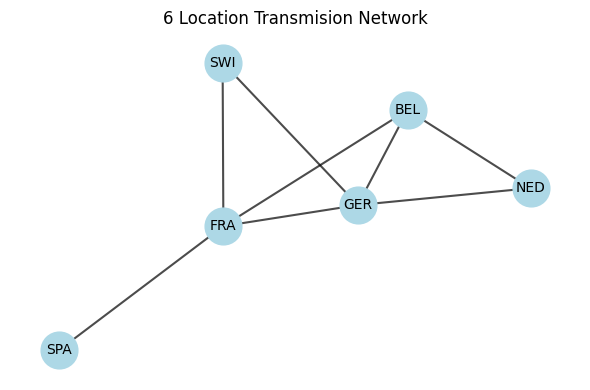

In [24]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S-N-S_GB2-G2-F2-S2-N2-S2_L8_c0_s0_p0_smp15.pkl", name = "6 Location Transmision Network")

## Constraint Data 3 Node

In [10]:
data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst.pkl"
CONFIG_FILE_NAME = "config.toml"
constraint_data = pickle.load(open(data_path, 'rb'))



In [11]:
constraint_data.pUnitInvestment.shape

torch.Size([32768, 6])

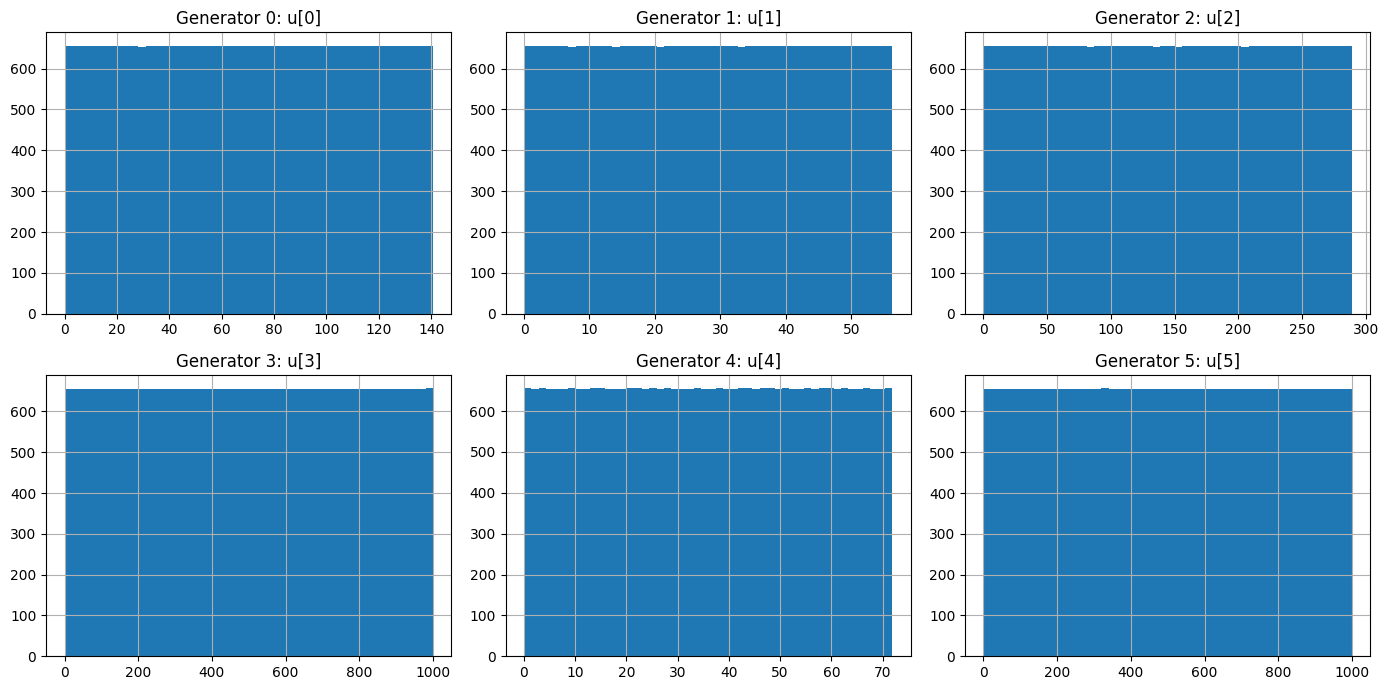

In [12]:
import matplotlib.pyplot as plt

U = constraint_data.pUnitInvestment
if hasattr(U, "detach"):
    U = U.detach().cpu().numpy()   # shape [B, 6]

B, G = U.shape
assert G == 6, f"Expected 6 generators, got {G}"

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for g in range(6):
    ax = axes[g]
    ax.hist(U[:, g], bins=50)
    ax.set_title(f"Generator {g}: u[{g}]")
    ax.grid(True)

plt.tight_layout()
plt.show()

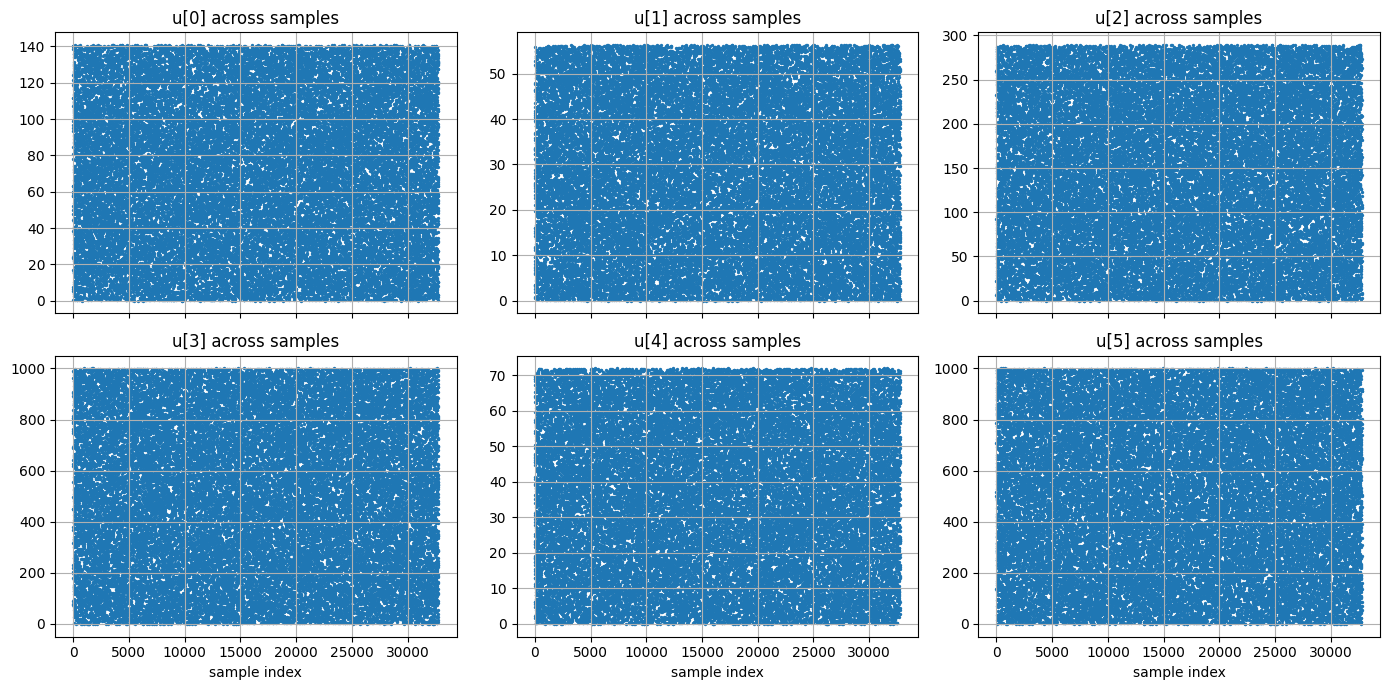

In [13]:
import numpy as np
import matplotlib.pyplot as plt

U = constraint_data.pUnitInvestment
if hasattr(U, "detach"):
    U = U.detach().cpu().numpy()

B, G = U.shape
assert G == 6, f"Expected 6 generators, got {G}"

x = np.arange(B)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.ravel()

for g in range(6):
    ax = axes[g]
    ax.scatter(x, U[:, g], s=2)
    ax.set_title(f"u[{g}] across samples")
    ax.grid(True)

axes[3].set_xlabel("sample index")
axes[4].set_xlabel("sample index")
axes[5].set_xlabel("sample index")

plt.tight_layout()
plt.show()

In [16]:
import torch

U = constraint_data.pUnitInvestment
X = constraint_data.X
N = constraint_data.num_n
G = constraint_data.num_g

idxs = torch.randint(0, X.shape[0], (5,))
for i in idxs:
    cap_from_X = X[i, N:N+G]

    cap_recon = []
    for g_idx, g in enumerate(constraint_data.G):
        # if you want availability=1 for this dataset:
        ava = 1.0
        cap_recon.append(U[i, g_idx].item() * constraint_data.pUnitCap[g] * ava)
    cap_recon = torch.tensor(cap_recon, dtype=cap_from_X.dtype)

    print("i =", i.item())
    print("X cap    :", cap_from_X)
    print("recon cap:", cap_recon)
    print("max abs diff:", (cap_from_X - cap_recon).abs().max().item())
    print("----")

i = 28097
X cap    : tensor([ 6618.0929, 10699.9722, 41356.4018,     0.0000, 20606.9844,     0.0000],
       dtype=torch.float64)
recon cap: tensor([ 3849.8409,  6513.4677, 70193.9962, 49520.1978, 17774.8423,  5423.4035],
       dtype=torch.float64)
max abs diff: 49520.1978366822
----
i = 26161
X cap    : tensor([ 4972.2486, 13997.7184, 58590.8115,     0.0000, 24804.7193,     0.0000],
       dtype=torch.float64)
recon cap: tensor([ 3416.0778,  7486.9914,  3573.3801, 45175.6428,  3202.1928, 14006.9738],
       dtype=torch.float64)
max abs diff: 55017.43143644884
----
i = 15770
X cap    : tensor([  138.2481,  8513.5354, 68985.7984,   284.3079, 31601.1726, 12094.8936],
       dtype=torch.float64)
recon cap: tensor([ 6233.8465,  9763.1986, 10073.2105, 45063.7892, 32065.5846, 24888.2966],
       dtype=torch.float64)
max abs diff: 58912.58788121976
----
i = 6257
X cap    : tensor([ 5938.4786,  9044.7621, 43405.8382,    57.8122, 48420.7130,   555.0373],
       dtype=torch.float64)
recon cap: 

In [15]:
data_path = "experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
CONFIG_FILE_NAME = "config.toml"
non_const_data = pickle.load(open(data_path, 'rb'))


import torch, numpy as np

U = constraint_data.pUnitInvestment
X = constraint_data.X  # [B, N+G] in your case

N = constraint_data.num_n
G = constraint_data.num_g

idxs = torch.randint(0, X.shape[0], (5,))
for i in idxs:
    cap_from_X = X[i, N:N+G]
    # reconstruct cap from U * Pmax * availability (availability may vary by t in your build_X)
    # If you use GenAva=1 or fixed t, just compare rough magnitude:
    print(i.item(), cap_from_X, U[i])


8064 tensor([ 7461.2611,  5230.6498, 29935.5826,     0.0000, 38318.4596,     0.0000],
       dtype=torch.float64) tensor([ 14.7370,  53.2273, 199.7838,  73.6109,   9.9048, 500.7798],
       dtype=torch.float64)
17713 tensor([ 3629.4001,  7742.7224,  2136.5661,  1978.3295,  6347.7452, 13157.0941],
       dtype=torch.float64) tensor([ 98.5836,  38.4084, 226.5365, 236.1934,  51.7162, 402.4968],
       dtype=torch.float64)
6633 tensor([  834.3557,  4299.0483, 42813.2788,  3664.2568, 64974.3306,  2525.2622],
       dtype=torch.float64) tensor([ 37.9257,  31.5283, 209.9053, 547.0678,   8.8222, 403.5774],
       dtype=torch.float64)
10618 tensor([ 1281.1720,  9834.1703, 52928.2907, 15582.1104, 22184.1624,  3678.8140],
       dtype=torch.float64) tensor([  5.5292,  31.1919, 210.5840, 242.6706,  24.9563, 723.3518],
       dtype=torch.float64)
23483 tensor([  405.9415,  1219.9286, 15091.7783,     0.0000, 64558.8042,     0.0000],
       dtype=torch.float64) tensor([ 22.1426,  44.7030, 172.0803, 5